# __Preprocesamiento de los datos__

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import holidays
import seaborn as sns

## Cargar datos

In [41]:
df1 = pd.read_excel('../data/Afluencia_2021.xlsx')
df2 = pd.read_excel('../data/Afluencia_2022.xlsx')
df3 = pd.read_excel('../data/Afluencia_2023.xlsx')
df4 = pd.read_excel('../data/Afluencia_2024.xlsx')
df5 = pd.read_excel('../data/Afluencia_2025.xlsx')

df_total = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
df_total

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20220,2025-09-30 00:00:00,LÍNEA K,2430.0,2828.0,2543.0,2160.0,1852.0,1345.0,1111.0,1204.0,...,753.0,1026.0,860.0,624.0,525.0,559.0,270.0,100.0,NaN,23385
20221,2025-09-30 00:00:00,LÍNEA M,381.0,1056.0,931.0,711.0,452.0,364.0,303.0,352.0,...,494.0,659.0,659.0,1178.0,891.0,526.0,402.0,306.0,74.0,10881
20222,2025-09-30 00:00:00,LÍNEA O,265.0,1592.0,1723.0,1820.0,1195.0,1190.0,850.0,1091.0,...,1145.0,1529.0,1810.0,1231.0,1119.0,904.0,825.0,310.0,14.0,21785
20223,2025-09-30 00:00:00,LÍNEA P,1315.0,3172.0,2793.0,2575.0,1621.0,1065.0,735.0,987.0,...,708.0,874.0,979.0,625.0,482.0,579.0,386.0,157.0,3.0,21684


In [42]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Fecha                                20225 non-null  object 
 1   Linea                                20225 non-null  object 
 2   04:00:00                             17109 non-null  float64
 3   05:00:00                             17186 non-null  float64
 4   06:00:00                             17190 non-null  float64
 5   07:00:00                             17204 non-null  float64
 6   08:00:00                             19301 non-null  float64
 7   09:00:00                             20177 non-null  float64
 8   10:00:00                             20169 non-null  float64
 9   11:00:00                             20160 non-null  float64
 10  12:00:00                             20166 non-null  float64
 11  13:00:00                    

## Limpiar datos

In [43]:
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104


In [44]:
# convertir valores nulos a cero
df_total.fillna(0, inplace=True)
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,0.0,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,0.0,0.0,31911
1,2021-01-01 00:00:00,LÍNEA B,0.0,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,0.0,0.0,0.0,4050
2,2021-01-01 00:00:00,LÍNEA K,0.0,0.0,0.0,0.0,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,0.0,0.0,0.0,1714
3,2021-01-01 00:00:00,LÍNEA J,0.0,0.0,0.0,0.0,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,0.0,0.0,1256
4,2021-01-01 00:00:00,LÍNEA 1,0.0,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,0.0,0.0,6104


In [45]:
# convertir campos float a enteros
cols_float = df_total.select_dtypes(include='float').columns
df_total[cols_float] = df_total[cols_float].astype(int)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Fecha                                20225 non-null  object
 1   Linea                                20225 non-null  object
 2   04:00:00                             20225 non-null  int64 
 3   05:00:00                             20225 non-null  int64 
 4   06:00:00                             20225 non-null  int64 
 5   07:00:00                             20225 non-null  int64 
 6   08:00:00                             20225 non-null  int64 
 7   09:00:00                             20225 non-null  int64 
 8   10:00:00                             20225 non-null  int64 
 9   11:00:00                             20225 non-null  int64 
 10  12:00:00                             20225 non-null  int64 
 11  13:00:00                             2022

In [46]:
# convertir campo Fecha a datetime
df_total['Fecha'] = pd.to_datetime(df_total['Fecha'], dayfirst=True)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Fecha                                20225 non-null  datetime64[ns]
 1   Linea                                20225 non-null  object        
 2   04:00:00                             20225 non-null  int64         
 3   05:00:00                             20225 non-null  int64         
 4   06:00:00                             20225 non-null  int64         
 5   07:00:00                             20225 non-null  int64         
 6   08:00:00                             20225 non-null  int64         
 7   09:00:00                             20225 non-null  int64         
 8   10:00:00                             20225 non-null  int64         
 9   11:00:00                             20225 non-null  int64         
 10  12:00:00  

In [47]:
# quitar la palabra Linea del campo Linea
df_total['Linea'] = df_total['Linea'].str.replace('LÍNEA', '', regex=False)
df_total['Linea'] = df_total['Linea'].str.strip()
df_total.sample(10)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
19697,2025-08-17,2,8,177,239,267,215,320,483,351,...,394,479,474,362,557,301,170,24,0,6330
5161,2022-03-30,2,139,737,1021,1057,899,826,920,999,...,1346,1791,2055,1729,1202,899,538,225,5,19595
12206,2023-11-19,1,396,1815,2144,2183,2105,2553,2851,2616,...,3022,3056,2997,2808,2277,2275,2021,229,0,44404
18500,2025-05-06,P,1121,3276,3382,2462,1415,1076,823,1369,...,656,839,1235,650,462,661,490,86,0,22513
2906,2021-09-19,2,16,144,165,147,174,211,293,278,...,297,406,344,407,361,261,137,20,0,4755
6783,2022-08-15,K,0,0,0,0,529,991,1213,1265,...,1308,1417,1392,948,842,681,347,94,0,14826
9892,2023-05-05,J,1534,2600,2458,2133,1355,951,779,813,...,619,698,698,527,387,349,207,73,76,18444
7656,2022-10-29,B,2398,5070,5884,5852,4496,4279,4306,4829,...,5877,5686,5177,4469,3352,2942,2440,1649,18,88723
3842,2021-12-08,M,0,0,0,0,2,287,238,265,...,420,432,456,451,261,264,298,174,0,4559
19882,2025-09-02,1,2784,8274,10312,10090,6301,5173,4261,4847,...,5977,8883,10383,7268,4576,3314,2601,1331,35,111575


In [48]:
# cambiar nombre de la variable 'Total general (Número de pasajeros)'
df_total = df_total.rename(columns={'Total general (Número de pasajeros)':'Total pasajeros'})
df_total.sample()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros
2341,2021-08-03,B,2518,6085,7309,5763,3845,3152,2967,2953,...,3590,5312,7625,5605,2982,2164,1566,826,7,73600


In [49]:
# seleccionar columnas que representan horas
hours_cols = [col for col in df_total.columns if col not in ['Fecha', 'Linea', 'Total pasajeros']]

# convertir a formato largo
df_long = df_total.melt(
    id_vars=['Fecha', 'Linea', 'Total pasajeros'],
    value_vars=hours_cols,
    var_name='Hora',
    value_name='Usuarios'
)

df_long.head()

,Fecha,Linea,Total pasajeros,Hora,Usuarios
0,2021-01-01,A,31911,04:00:00,0
1,2021-01-01,B,4050,04:00:00,0
2,2021-01-01,K,1714,04:00:00,0
3,2021-01-01,J,1256,04:00:00,0
4,2021-01-01,1,6104,04:00:00,0


In [ ]:
# ordenar las var
df_long.tail()

,Fecha,Linea,Total pasajeros,Hora,Usuarios
404495,2025-09-30,K,23385,23:00:00,0
404496,2025-09-30,M,10881,23:00:00,74
404497,2025-09-30,O,21785,23:00:00,14
404498,2025-09-30,P,21684,23:00:00,3
404499,2025-09-30,T-A,62053,23:00:00,61


In [ ]:
dflla

## Features ingening

In [51]:
# crear un campo que almacene el respectivo año de cada fecha
df_total['Year'] = df_total['Fecha'].dt.year
df_total.head()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros,Year
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,2900,3269,3314,2273,1329,12,0,0,31911,2021
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,321,421,432,215,157,0,0,0,4050,2021
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,258,189,122,103,38,0,0,0,1714,2021
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,179,132,135,69,42,3,0,0,1256,2021
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,579,624,574,399,231,17,0,0,6104,2021


In [52]:
# crear un campo que almacene los dias de la semana
df_total['Day'] = df_total['Fecha'].dt.day_name()
df_total.head()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros,Year,Day
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,3269,3314,2273,1329,12,0,0,31911,2021,Friday
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,421,432,215,157,0,0,0,4050,2021,Friday
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,189,122,103,38,0,0,0,1714,2021,Friday
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,132,135,69,42,3,0,0,1256,2021,Friday
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,624,574,399,231,17,0,0,6104,2021,Friday


In [53]:
# crear un campo que almacene los meses de cada fecha
df_total['Month'] = df_total['Fecha'].dt.month_name()
df_total.sample(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros,Year,Day,Month
12772,2024-01-05,L,0,0,0,0,0,300,456,706,...,5,0,0,0,0,0,4603,2024,Friday,January
2587,2021-08-23,M,232,663,692,518,289,216,207,243,...,854,674,355,212,163,46,7639,2021,Monday,August
6549,2022-07-26,T-A,1293,4018,4117,4161,3026,2243,2003,2497,...,5030,3469,2283,1550,1014,35,56472,2022,Tuesday,July
12839,2024-01-11,B,2506,5842,6939,6012,4266,3616,3388,3338,...,5662,3668,2577,1736,1056,9,81197,2024,Thursday,January
12631,2023-12-24,P,0,0,0,0,84,924,829,765,...,774,726,720,52,0,0,8957,2023,Sunday,December


## EDA

### Promedio de pasajeros por hora para el periodo que va del 2021 al 2025 

In [54]:
# listar las horas, lineas y años
horas = [c for c in df_total.columns if c not in ("Fecha", "Linea", "Year", "Total Pasajeros", 'Month', 'Day')]
lineas = sorted(df_total["Linea"].unique())
year = sorted(df_total["Year"].unique())

# transformar formato de los datos en largo
df_long = df_total.melt(
    id_vars=["Fecha", "Linea", "Year"],
    value_vars=horas,
    var_name="Hora",
    value_name="Pasajeros"
)

# obtener el promedio de pasajeros para cada año, por linea y por hora.
promedio = (
    df_long
    .groupby(["Year", "Linea", "Hora"])["Pasajeros"]
    .mean()
    .reset_index()
)

# ordenar los datos cronologicamente
promedio["Hora_idx"] = pd.Categorical(promedio["Hora"], categories=horas, ordered=True)
promedio = promedio.sort_values(["Year", "Linea", "Hora_idx"])
promedio

,Year,Linea,Hora,Pasajeros,Hora_idx
0,2021,1,04:00:00,1919.353425,04:00:00
1,2021,1,05:00:00,5154.684932,05:00:00
2,2021,1,06:00:00,6349.567123,06:00:00
3,2021,1,07:00:00,5771.205479,07:00:00
4,2021,1,08:00:00,3931.764384,08:00:00
...,...,...,...,...,...
1255,2025,T-A,20:00:00,2051.644689,20:00:00
1256,2025,T-A,21:00:00,1638.890110,21:00:00
1257,2025,T-A,22:00:00,1010.791209,22:00:00
1258,2025,T-A,23:00:00,52.274725,23:00:00


ValueError: operands could not be broadcast together with shapes (20,) (21,) 

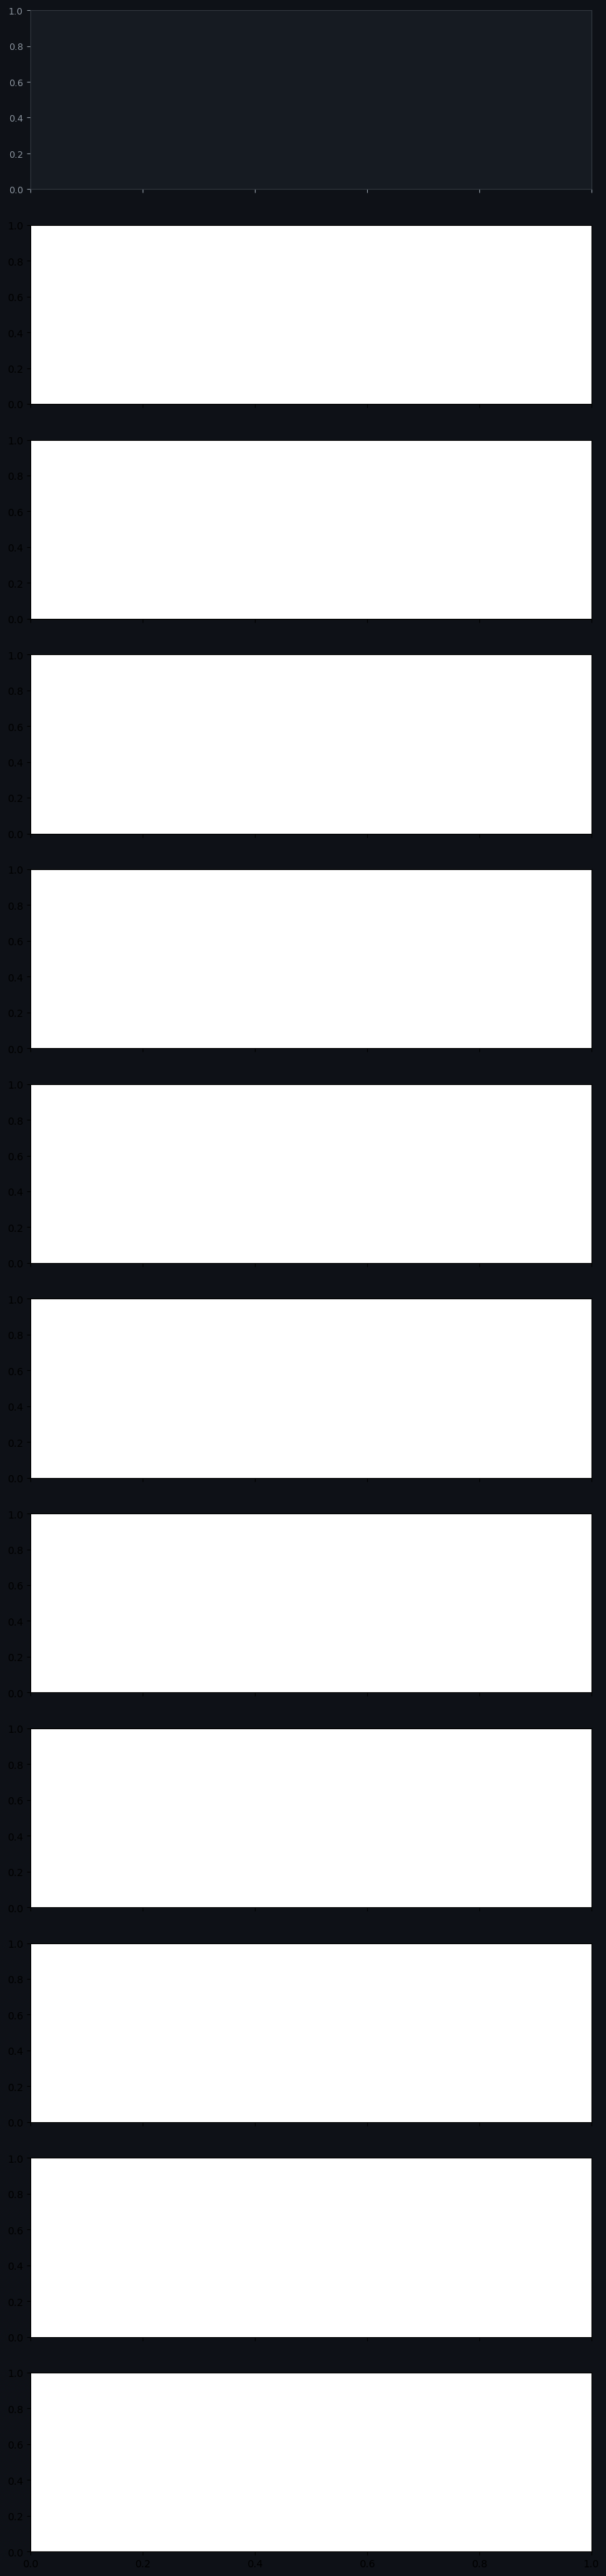

In [55]:
# un color para cada año
PALETA = {
    2021: "#378ADD",
    2022: "#1D9E75",
    2023: "#BA7517",
    2024: "#7F77DD",
    2025: "#D85A30",
}
 
horas = [f"{h:02d}" for h in range(4, 24)]
HORA_LABELS = [h[:5] for h in horas]

# obtener cantidad de lineas
n_lineas = len(lineas)

# crear una subgrafica para cada linea del metro
fig, axes = plt.subplots(
    n_lineas, 1,
    figsize=(10, 3.8 * n_lineas),
    sharex=True,
    facecolor="#0e1117"
)

if n_lineas == 1:
    axes = [axes]

# definir color de fondo de la figura 
fig.patch.set_facecolor("#0e1117")
 
for ax, linea in zip(axes, lineas):
    ax.set_facecolor("#161b22")
    ax.spines[:].set_color("#30363d")
    ax.tick_params(colors="#8b949e", labelsize=9)
    ax.yaxis.label.set_color("#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
 
    datos_linea = promedio[promedio["Linea"] == linea].copy()
    y_max_global = 0
 
    for año in year:
        datos_año = datos_linea[datos_linea["Year"] == año].copy()
        if datos_año.empty:
            continue
        y = datos_año["Pasajeros"].values
        x = np.arange(len(horas))
        color = PALETA[año]
        ax.fill_between(x, y, alpha=0.18, color=color)
        ax.plot(x, y, color=color, linewidth=1.8, label=str(año))
        y_max_global = max(y_max_global, y.max())
 
    # Marcar hora pico del promedio total
    promedio_total = datos_linea.groupby("Hora_idx", observed=True)["Pasajeros"].mean().values
    idx_pico = np.argmax(promedio_total)
    ax.axvline(idx_pico, color="#f0f0f0", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.annotate(
        f"Pico: {HORA_LABELS[idx_pico]}",
        xy=(idx_pico, y_max_global * 0.95),
        xytext=(idx_pico + 0.4, y_max_global * 0.95),
        fontsize=8, color="#f0f0f0", alpha=0.7,
        va="top"
    )
 
    ax.set_ylabel("Promedio pasajeros", fontsize=9, color="#8b949e")
    ax.set_title(f"Línea {linea}", fontsize=12, fontweight="bold",
                 color="#e6edf3", loc="left", pad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}".replace(",", ".")
    ))
    ax.set_ylim(0, y_max_global * 1.12)
    ax.grid(axis="y", color="#30363d", linewidth=0.6, linestyle=":")
    ax.grid(axis="x", color="#30363d", linewidth=0.4, linestyle=":")
 
    # Leyenda dentro del panel
    leg = ax.legend(
        title="Año", title_fontsize=8,
        fontsize=8, loc="upper right",
        framealpha=0.3, frameon=True,
        labelcolor="#c9d1d9",
        facecolor="#161b22", edgecolor="#30363d"
    )
    leg.get_title().set_color("#8b949e")
 
# Eje X compartido
axes[-1].set_xticks(np.arange(len(horas)))
axes[-1].set_xticklabels(HORA_LABELS, rotation=0, ha="center", fontsize=8, color="#8b949e")
axes[-1].set_xlabel("Hora del día", fontsize=10, color="#8b949e")
 
fig.suptitle(
    "Promedio de pasajeros por hora\nMetro de Medellín (2021–2025)",
    fontsize=15, fontweight="bold", color="#e6edf3",
    y=1.005
)

plt.show()

### Heatmap de hora x linea

In [ ]:
# clasificar los dias por habiles y fin de semana
df_total['tipo_dia'] = df_total['Fecha'].dt.day_of_week.map(
    lambda d: 'habil' if d < 5 else 'fin de semana'
)

# clasificar los dias festivos como fin de semana
festivos = holidays.Colombia(years=range(2021, 2026))
df_total.loc[df_total['Fecha'].isin(festivos), 'tipo_dia'] = 'fin de semana'

# convertir de formato ancho a largo
horas = [c for c in df_total.columns if c not in ('Fecha', 'Linea', 'tipo_dia', 'Total Pasajeros', 'Year', 'Day', 'Month')]

df_long = df_total.melt(
    id_vars=['Linea', 'tipo_dia'],
    value_vars=horas,
    var_name='Hora',
    value_name='Pasajeros'
)

df_long.sample(5)

,Linea,tipo_dia,Hora,Pasajeros
166546,2,habil,12,1170
258612,K,habil,16,987
113981,M,habil,09,295
274065,O,habil,17,1302
225556,J,habil,15,488


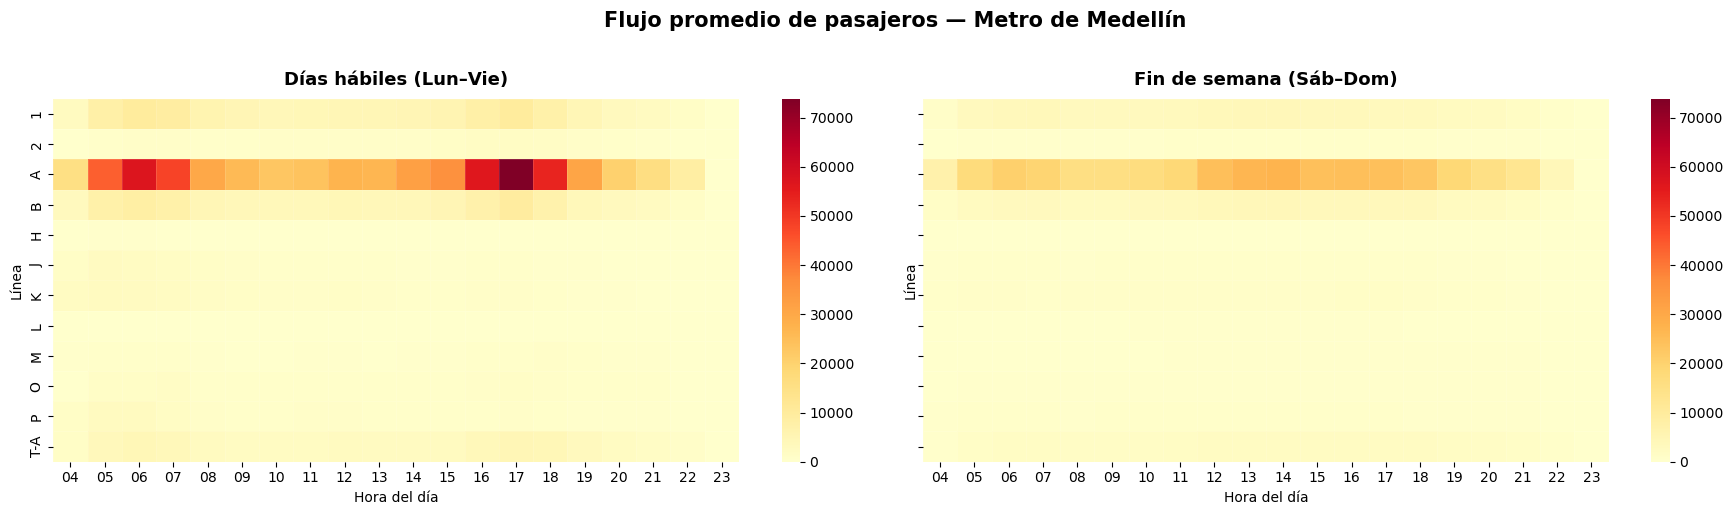

In [ ]:
# funcion de la matriz linea x hora
def build_matrix(tipo):
    subset = df_long[df_long['tipo_dia'] == tipo]
    matriz = subset.pivot_table(
        index='Linea',
        columns='Hora',
        values='Pasajeros',
        aggfunc='mean'
    )

    # ordenar columnas cronologicamente
    matriz = matriz[sorted(matriz.columns)]
    return matriz

# matriz de los dias habiles y fines de semana
mat_habil = build_matrix('habil')
mat_finde = build_matrix('fin de semana')

# definir la misma escala de color a cada heatmap
vmax = max(mat_habil.values.max(), mat_finde.values.max())
paleta = 'YlOrRd'

# crear grafica de heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
hora_labels = [h[:5] for h in mat_habil.columns]

for ax, mat, titulo in [(ax1, mat_habil, "Días hábiles (Lun–Vie)"), (ax2, mat_finde, "Fin de semana (Sáb–Dom)")]:

    sns.heatmap(
        mat, ax=ax,
        cmap=paleta, vmin=0, vmax=vmax,
        xticklabels=hora_labels,
        linewidths=0.4, linecolor="#ffffff20",
        annot=False,           # True si quieres números en celdas
        fmt=".0f", cbar=True
    )

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Línea")
    ax.tick_params(axis="x", rotation=0)

    fig.suptitle("Flujo promedio de pasajeros — Metro de Medellín",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("heatmap_metro.png", dpi=150, bbox_inches="tight")
plt.show()

### Verificar la cantidad de dias por año

In [ ]:
df_total.Linea.unique()

array(['A', 'B', 'K', 'J', '1', '2', 'T-A', 'M', 'H', 'O', 'L', 'P'],
      dtype=object)

In [ ]:
df_fechas_lineas = (
    df_total.groupby(['Linea', 'Year'])['Fecha']
    .nunique()
    .reset_index()
    .pivot(index='Linea', columns='Year', values='Fecha')
    .reset_index()
)

df_fechas_lineas.columns.name = None
df_fechas_lineas

,Linea,2021,2022,2023,2024,2025
0,1,365,365,365,365,273
1,2,362,365,365,365,273
2,A,365,365,365,365,273
3,B,365,365,364,365,273
4,H,362,357,362,362,268
5,J,359,357,358,358,264
6,K,354,354,352,338,268
7,L,289,316,314,319,234
8,M,363,362,364,362,269
9,O,365,365,365,365,273


### Mostrar fechas en las que estuvo sin afluencia las lineas

In [ ]:
# fechas en la que la afluencia fue de menos de 10 personas
df_sin_afluencia = df_total[df_total['Total Pasajeros'] < 10][['Fecha', 'Linea', 'Total Pasajeros']]
df_sin_afluencia

,Fecha,Linea,Total Pasajeros
1660,2021-06-04,P,1
1672,2021-06-05,P,1
1675,2021-06-06,K,1
1705,2021-06-09,K,1
1714,2021-06-09,P,6
2416,2021-08-09,L,1
3417,2021-11-02,M,1
3577,2021-11-16,L,1
3898,2021-12-13,L,1
5903,2022-05-31,L,1
